In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Question 3 — Custom histogram equalization (`runway.png`)

We implement **global histogram equalization** from the image histogram and its **CDF** $C(k)=\sum_{i\le k}h(i)$. For 8-bit intensities,

$$s_k = \mathrm{round}\left(\frac{C(k)-C_{\min}}{MN-C_{\min}}\cdot 255\right),$$

where $C_{\min}$ is the CDF at the **smallest** gray level that actually occurs (so unused black levels do not stretch the mapping). The output is $s[x,y]=s_{f[x,y]}$ via a **lookup table** (no `cv2.equalizeHist`).

**Runway:** we show **grayscale** equalization and **color** equalization by equalizing only the **Y** channel in **YCrCb** (keeps chroma plausible).

In [2]:
def histogram_equalize(gray: np.ndarray) -> np.ndarray:
    """Equalize a single-channel uint8 image using its histogram and CDF.

    Parameters
    ----------
    gray : ndarray, shape (H, W), dtype uint8

    Returns
    -------
    ndarray, shape (H, W), dtype uint8
    """
    if gray.dtype != np.uint8:
        raise TypeError("Expected uint8 grayscale image.")
    if gray.ndim != 2:
        raise ValueError("Expected 2D grayscale image.")

    h, w = gray.shape
    n = h * w

    flat = gray.ravel()
    hist = np.bincount(flat, minlength=256)
    cdf = np.cumsum(hist.astype(np.float64))

    first = np.argmax(hist > 0)
    cdf_min = cdf[first]
    denom = n - cdf_min
    if denom <= 0:
        return gray.copy()

    lut = np.round((cdf - cdf_min) / denom * 255.0).astype(np.uint8)
    return lut[gray]


def histogram_equalize_bgr_y(bgr: np.ndarray) -> np.ndarray:
    """Equalize luminance only: BGR → YCrCb, equalize Y, merge, BGR."""
    ycrcb = cv2.cvtColor(bgr, cv2.COLOR_BGR2YCrCb)
    y, cr, cb = cv2.split(ycrcb)
    y_eq = histogram_equalize(y)
    return cv2.cvtColor(cv2.merge([y_eq, cr, cb]), cv2.COLOR_YCrCb2BGR)

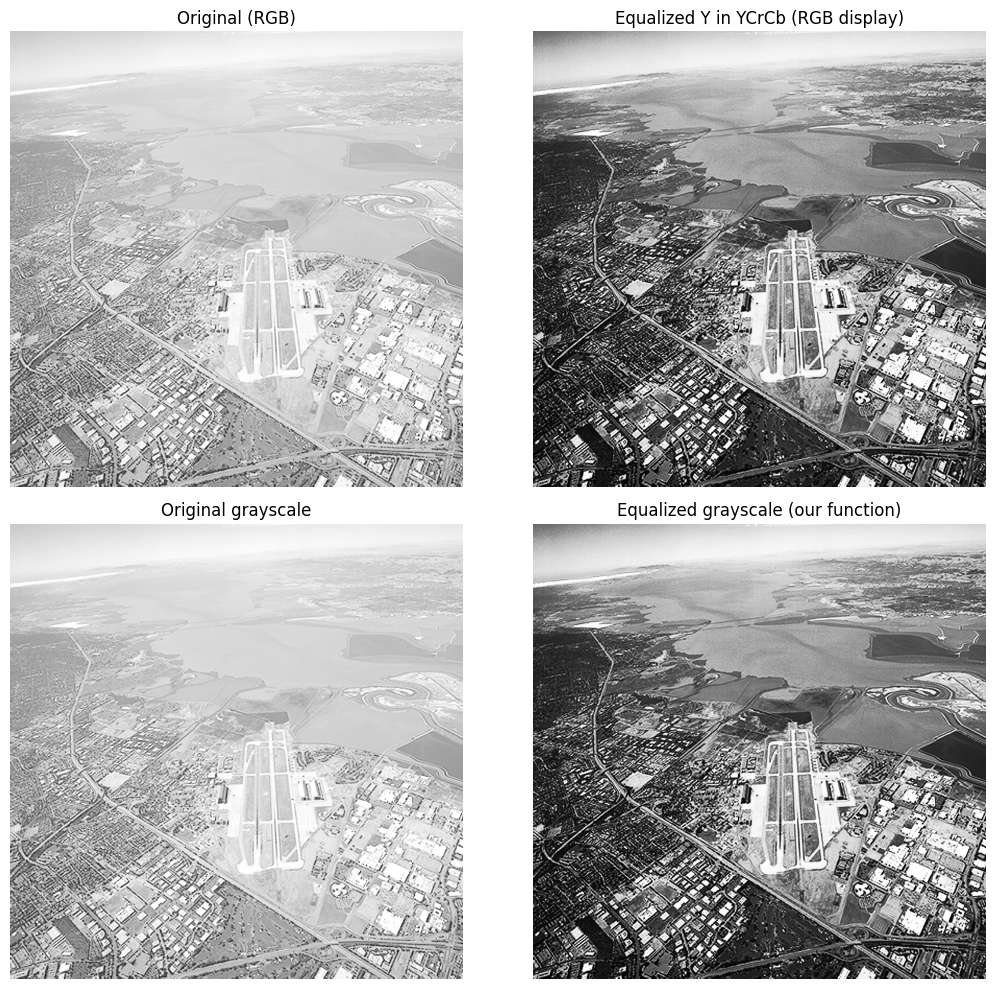

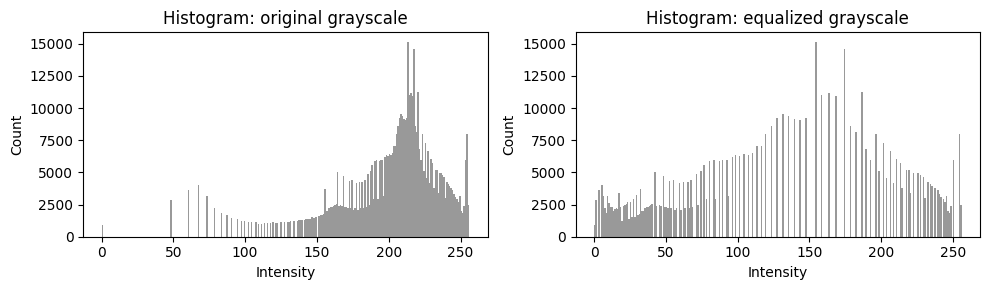

In [3]:
path = "images/runway.png"
bgr = cv2.imread(path)
if bgr is None:
    raise FileNotFoundError(path)

gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
gray_eq = histogram_equalize(gray)
bgr_eq = histogram_equalize_bgr_y(bgr)

rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
rgb_eq = cv2.cvtColor(bgr_eq, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(2, 2, figsize=(11, 10))
axes[0, 0].imshow(rgb)
axes[0, 0].set_title("Original (RGB)")
axes[0, 1].imshow(rgb_eq)
axes[0, 1].set_title("Equalized Y in YCrCb (RGB display)")
axes[1, 0].imshow(gray, cmap="gray")
axes[1, 0].set_title("Original grayscale")
axes[1, 1].imshow(gray_eq, cmap="gray")
axes[1, 1].set_title("Equalized grayscale (our function)")
for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(gray.ravel(), bins=256, range=(0, 256), color="gray", alpha=0.8)
axes[0].set_title("Histogram: original grayscale")
axes[1].hist(gray_eq.ravel(), bins=256, range=(0, 256), color="gray", alpha=0.8)
axes[1].set_title("Histogram: equalized grayscale")
for ax in axes:
    ax.set_xlabel("Intensity")
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()